# BCI EEG Lab 1: RSVP Target vs Non-Target (P300)

Goal:
- Preprocess EEG
- Epoch around RSVP events
- Compare Target (T) vs Non-Target (NT) ERPs
- Quantify the P300 effect (300–600 ms)
- EOG channels for artifact detection





In [1]:
%pip install mne
%pip install numpy 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1) Load data and inspect metadata
Make sure these files are in the working directory:
- `RSVP_login_VPeal.vhdr`
- `RSVP_login_VPeal.eeg`
- `RSVP_login_VPeal.vmrk`


In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

raw = mne.io.read_raw_brainvision("RSVP_login_VPeal.vhdr", preload=True)

# get some information about our data
raw.info

Extracting parameters from RSVP_login_VPeal.vhdr...
Setting channel info structure...
Reading 0 ... 1513649  =      0.000 ...  3027.298 secs...


C:\Users\nzhan\AppData\Local\Temp\ipykernel_16888\1410373974.py:5: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision("RSVP_login_VPeal.vhdr", preload=True)


<Info | 7 non-empty values
 bads: []
 ch_names: F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, T7, C3, Cz, C4, T8, CP5, ...
 chs: 32 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 70.0 Hz
 meas_date: 2015-05-15 18:16:20 UTC
 nchan: 32
 projs: []
 sfreq: 500.0 Hz
>

In [3]:
print("Sampling rate:", raw.info["sfreq"], "Hz")
print("Channels:", len(raw.ch_names))

# Give the size of the data matrix
data, times = raw[:,:]
print('%s channels x %s samples' % (data.shape[0], data.shape[1]))

print("First 10 channel names:", raw.ch_names[:10])

Sampling rate: 500.0 Hz
Channels: 32
32 channels x 1513650 samples
First 10 channel names: ['F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7']


In [4]:
# here, we should rename 'EOGv1' channel into 'Fp1' because the mne doesn't recognize the name EOGv1'
raw.rename_channels({'EOGv1': 'Fp1'})

# To verify the change, you can print the updated list of channel names or check if 'Fp1' is in the list.
# For example, to check if 'Fp1' is now in the channel names:
if 'Fp1' in raw.ch_names:
    print(f"Channel 'Fp1' is present at index: {raw.ch_names.index('Fp1')}")
else:
    print("Channel 'Fp1' not found in channel names.")

Channel 'Fp1' is present at index: 31


## 2) Electrode layout + raw PSD sanity check


In [5]:
# different montage
print(mne.channels.get_builtin_montages())

['standard_1005', 'standard_1020', 'standard_alphabetic', 'standard_postfixed', 'standard_prefixed', 'standard_primed', 'biosemi16', 'biosemi32', 'biosemi64', 'biosemi128', 'biosemi160', 'biosemi256', 'easycap-M1', 'easycap-M10', 'easycap-M43', 'EGI_256', 'GSN-HydroCel-32', 'GSN-HydroCel-64_1.0', 'GSN-HydroCel-65_1.0', 'GSN-HydroCel-128', 'GSN-HydroCel-129', 'GSN-HydroCel-256', 'GSN-HydroCel-257', 'mgh60', 'mgh70', 'artinis-octamon', 'artinis-brite23', 'brainproducts-RNP-BA-128']


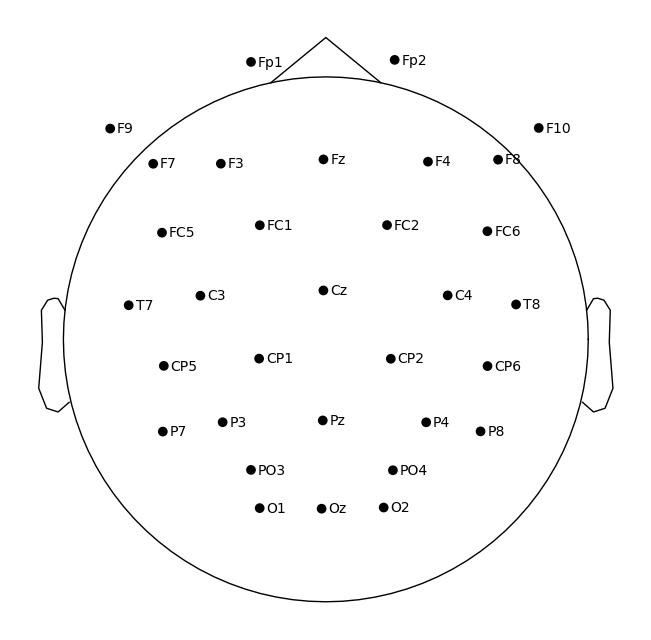

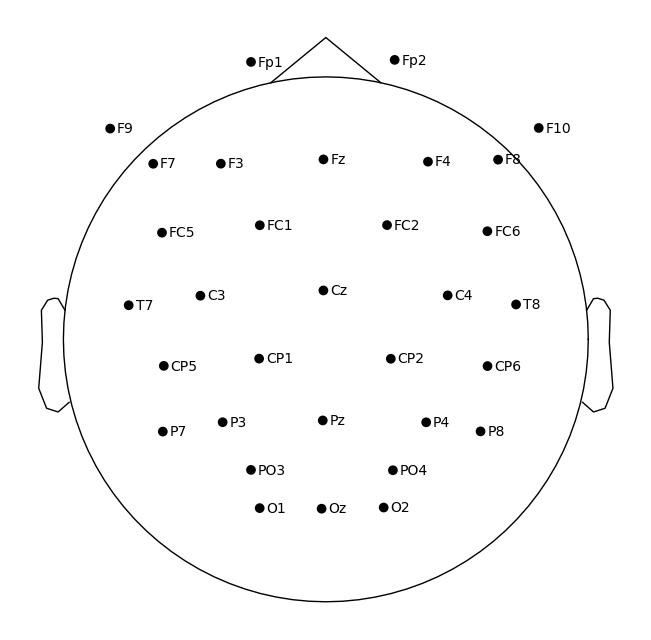

In [6]:
# Plot scalp maps
montage = mne.channels.make_standard_montage("standard_1020") # you can use different montage if needed
raw.set_montage(montage, on_missing="warn")

raw.plot_sensors(kind="topomap", show_names=True)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\nzhan\miniconda3\envs\mech_liquide\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


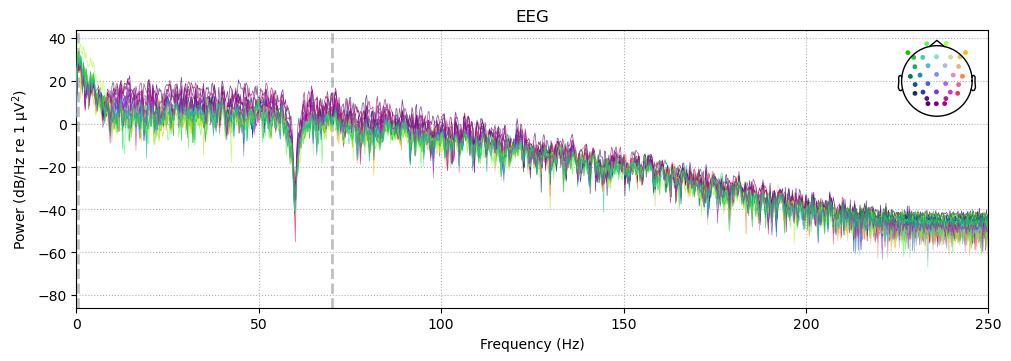

In [7]:
# look at raw power spectral densities
picks = mne.pick_types(raw.info, meg=False, eeg=True, eog=False,
                       stim=False, exclude='bads')

raw.plot_psd(area_mode='range', tmax=10.0, picks=picks, average=False);

## 3) Preprocess: low-pass

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method


- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 165 samples (0.330 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\nzhan\miniconda3\envs\mech_liquide\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


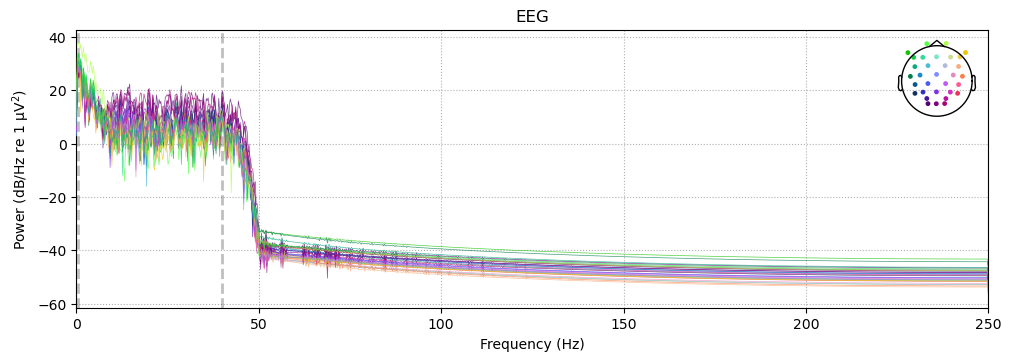

In [8]:
raw.filter(l_freq=None, h_freq=40., fir_design='firwin')
raw.plot_psd(area_mode='range', tmax=10.0, picks=picks, average=False);

## 3) Preprocess: Downsample

In [9]:
# Define the new sampling frequency (e.g., 100 Hz)
new_sf = 100

# Downsampling the data
raw.resample(sfreq=new_sf, npad='auto', window='boxcar')

# Save the downsampled data if needed
raw.save('RSVP_login_VPeal_100Hz_eeg.fif', overwrite=True)

Overwriting existing file.
Writing c:\Users\nzhan\Downloads\BCI assignment\RSVP_login_VPeal_100Hz_eeg.fif
Overwriting existing file.
Closing c:\Users\nzhan\Downloads\BCI assignment\RSVP_login_VPeal_100Hz_eeg.fif
[done]


[WindowsPath('c:/Users/nzhan/Downloads/BCI assignment/RSVP_login_VPeal_100Hz_eeg.fif')]

Let's check the new sampling frequency and visually confirm the downsampling with a Power Spectral Density (PSD) plot.

New Sampling rate: 100.0 Hz
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 10.010 (s)
Plotting power spectral density (dB=True).


c:\Users\nzhan\miniconda3\envs\mech_liquide\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


New data shape: 32 channels x 302730 samples


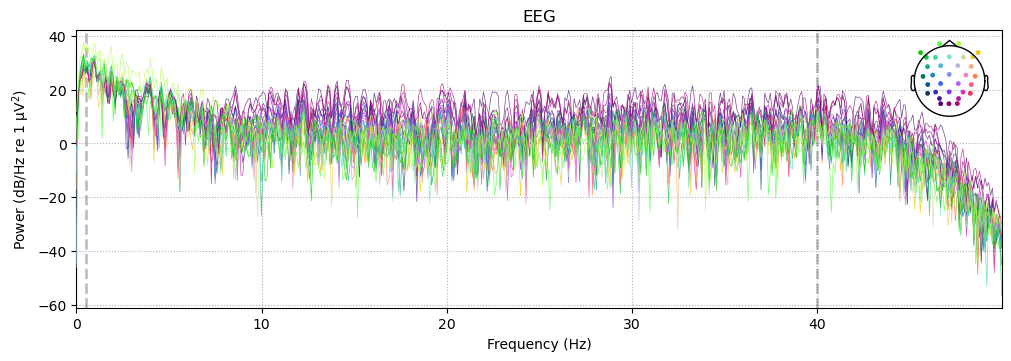

In [10]:
print("New Sampling rate:", raw.info["sfreq"], "Hz")

# Plot the PSD after downsampling to visually confirm the frequency range
raw.plot_psd(area_mode='range',  tmax=10.0, picks=picks, average=False, fmax=raw.info['sfreq'] / 2);

# Display data shape to see if number of samples changed
data, times = raw[:,:]
print('New data shape: %s channels x %s samples' % (data.shape[0], data.shape[1]))

## 4) Events from annotations

Used Annotations descriptions: [np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  5'), np.str_('Stimulus/S  6'), np.str_('Stimulus/S  7'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S  9'), np.str_('Stimulus/S 10'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 13'), np.str_('Stimulus/S 14'), np.str_('Stimulus/S 15'), np.str_('Stimulus/S 16'), np.str_('Stimulus/S 17'), np.str_('Stimulus/S 18'), np.str_('Stimulus/S 19'), np.str_('Stimulus/S 20'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S 23'), np.str_('Stimulus/S 24'), np.str_('Stimulus/S 25'), np.str_('Stimulus/S101'), np.str_('Stimulus/S102'), np.str_('Stimulus/S103'), np.str_('Stimulus/S121'), np.str_('Stimulus/S141'), np.str_('Stimulus/S142'), np.str_('Stimulus/S181'), np.str_('Stimulus/S182'), np.str_('Stimulus/S191'), np.str_('Stimulus/S192'), np.str_('Stimulus/S201'), np.str_('Stimulus/S202'), np.str

C:\Users\nzhan\AppData\Local\Temp\ipykernel_16888\375074224.py:8: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events[:15], sfreq=raw.info['sfreq'])


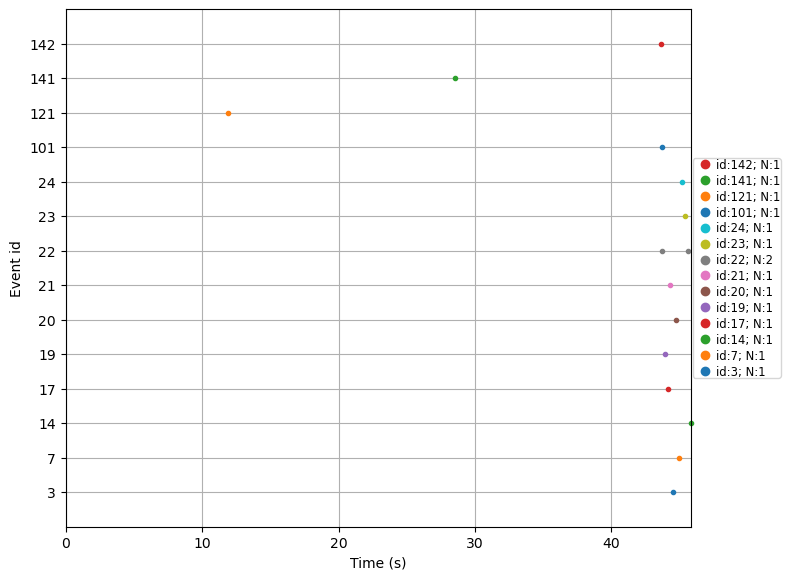

Event mapping from annotations:
  Stimulus/S  1 -> 1
  Stimulus/S  2 -> 2
  Stimulus/S  3 -> 3
  Stimulus/S  4 -> 4
  Stimulus/S  5 -> 5
  Stimulus/S  6 -> 6
  Stimulus/S  7 -> 7
  Stimulus/S  8 -> 8
  Stimulus/S  9 -> 9
  Stimulus/S 10 -> 10
  Stimulus/S 11 -> 11
  Stimulus/S 12 -> 12
  Stimulus/S 13 -> 13
  Stimulus/S 14 -> 14
  Stimulus/S 15 -> 15
  Stimulus/S 16 -> 16
  Stimulus/S 17 -> 17
  Stimulus/S 18 -> 18
  Stimulus/S 19 -> 19
  Stimulus/S 20 -> 20
  Stimulus/S 21 -> 21
  Stimulus/S 22 -> 22
  Stimulus/S 23 -> 23
  Stimulus/S 24 -> 24
  Stimulus/S 25 -> 25
  Stimulus/S101 -> 101
  Stimulus/S102 -> 102
  Stimulus/S103 -> 103
  Stimulus/S121 -> 121
  Stimulus/S141 -> 141
  Stimulus/S142 -> 142
  Stimulus/S181 -> 181
  Stimulus/S182 -> 182
  Stimulus/S191 -> 191
  Stimulus/S192 -> 192
  Stimulus/S201 -> 201
  Stimulus/S202 -> 202
  Stimulus/S203 -> 203
  Stimulus/S204 -> 204
  Stimulus/S205 -> 205
  Stimulus/S211 -> 211
  Stimulus/S212 -> 212
  Stimulus/S221 -> 221
  Stimulus/S2

In [11]:
# extracting events from raw
events, event_id_from_annotations = mne.events_from_annotations(raw)

print("First 15 events (Sample Index, Duration, Event ID):")
for event in events[:15]:
    print(f"  Sample Index: {event[0]}, Duration: {event[1]}, Event ID: {event[2]}")

mne.viz.plot_events(events[:15], sfreq=raw.info['sfreq'])


print("Event mapping from annotations:")
for key, value in event_id_from_annotations.items():
    print(f"  {key} -> {value}")

In [12]:
print("\nEvent counts:")
unique_ids, counts = np.unique(events[:, 2], return_counts=True)
for eid, count in zip(unique_ids, counts):
    label = [k for k, v in event_id_from_annotations.items() if v == eid][0]
    print(f"  Event ID {eid} ({label}): {count}")


Event counts:
  Event ID 1 (Stimulus/S  1): 151
  Event ID 2 (Stimulus/S  2): 149
  Event ID 3 (Stimulus/S  3): 152
  Event ID 4 (Stimulus/S  4): 149
  Event ID 5 (Stimulus/S  5): 150
  Event ID 6 (Stimulus/S  6): 150
  Event ID 7 (Stimulus/S  7): 150
  Event ID 8 (Stimulus/S  8): 150
  Event ID 9 (Stimulus/S  9): 152
  Event ID 10 (Stimulus/S 10): 150
  Event ID 11 (Stimulus/S 11): 149
  Event ID 12 (Stimulus/S 12): 149
  Event ID 13 (Stimulus/S 13): 148
  Event ID 14 (Stimulus/S 14): 152
  Event ID 15 (Stimulus/S 15): 148
  Event ID 16 (Stimulus/S 16): 151
  Event ID 17 (Stimulus/S 17): 149
  Event ID 18 (Stimulus/S 18): 149
  Event ID 19 (Stimulus/S 19): 149
  Event ID 20 (Stimulus/S 20): 149
  Event ID 21 (Stimulus/S 21): 150
  Event ID 22 (Stimulus/S 22): 151
  Event ID 23 (Stimulus/S 23): 149
  Event ID 24 (Stimulus/S 24): 153
  Event ID 25 (Stimulus/S 25): 151
  Event ID 101 (Stimulus/S101): 7
  Event ID 102 (Stimulus/S102): 6
  Event ID 103 (Stimulus/S103): 2
  Event ID 121 (S

## 5) Epoching

In [13]:
# define the custom event_id mapping for all specific target (T) and non-target (NT) stimuli.
event_id = {'T1': 1, 'T2': 2, 'T3': 3,
            'NT1':4, 'NT2': 5, 'NT3': 6, 'NT4':7, 'NT5':8, 'NT6':9, 'NT7':10,
            'NT8':11, 'NT9':12, 'NT10':13, 'NT11':14, 'NT12':15, 'NT13':16,
            'NT14':17, 'NT15':18, 'NT16':19, 'NT17':20, 'NT18':21, 'NT19':22,
            'NT20':23, 'NT21':24, 'NT22':25}

# create epochs (segment of EEG data time-locked to a specific event) from the raw data around the defined events.
epochs = mne.Epochs(raw,
                    events,
                    event_id,
                    tmin=-0.2,        # start of the epoch relative to the event onset (200 ms before).
                    tmax=1,           # end of the epoch relative to the event onset (1000 ms after).
                    baseline=(None, 0),
                    detrend=1,
                    preload=True)

epochs.apply_baseline((-0.2, 0))

# combine specific event IDs into broader categories for analysis.
epochs = mne.epochs.combine_event_ids(epochs, ['T1','T2','T3'], {'T': 112}, copy=True)
epochs = mne.epochs.combine_event_ids(epochs, ['NT1', 'NT2', 'NT3', 'NT4', 'NT5', 'NT6', 'NT7', 'NT8', 'NT9',
                                              'NT10', 'NT11', 'NT12', 'NT13', 'NT14', 'NT15', 'NT16', 'NT17',
                                              'NT18', 'NT19', 'NT20', 'NT21', 'NT22'], {'NT': 113}, copy=True)

# summary of the created epochs, showing the number of epochs for each category.
print(epochs)
print(epochs["T"], epochs["NT"])

n_T = len(epochs['T'])
n_NT = len(epochs['NT'])
print(f"Target epochs: {n_T}")
print(f"Non-target epochs: {n_NT}")
print(f"Ratio NT:T = {n_NT/n_T:.1f}:1")

Not setting metadata
3750 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 3750 events and 121 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
<Epochs | 3750 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~110.8 MiB, data loaded,
 'T': 452
 'NT': 3298>
<Epochs | 452 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~13.4 MiB, data loaded,
 'T': 452> <Epochs | 3298 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~97.5 MiB, data loaded,
 'NT': 3298>
Target epochs: 452
Non-target epochs: 3298
Ratio NT:T = 7.3:1


## 6) ERP comparison

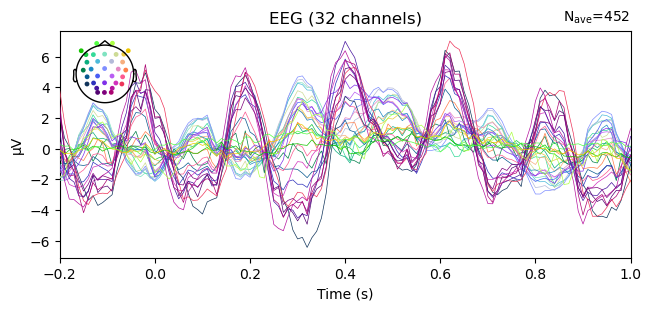

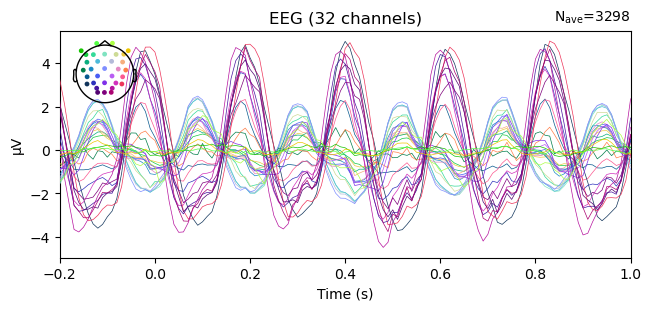

In [14]:
target = epochs['T'].average()
non_target = epochs['NT'].average()

fig1 = target.plot(spatial_colors=True)
fig2 = non_target.plot(spatial_colors=True)


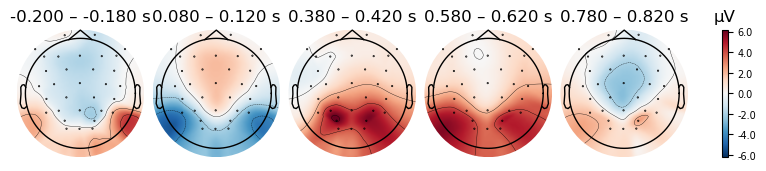

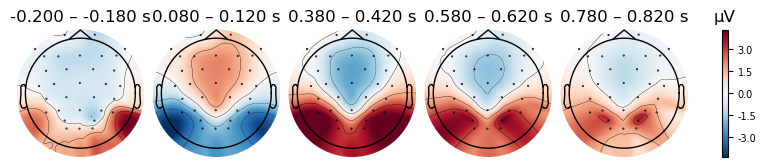

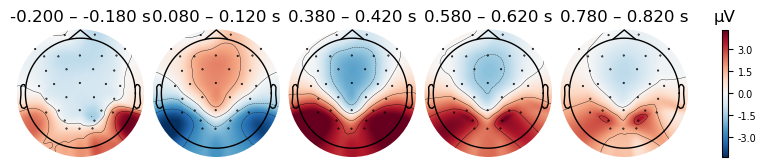

In [15]:
times_to_show = [-0.2, 0.1, 0.4, 0.6, 0.8]
target.plot_topomap(times=times_to_show, average=0.05)
non_target.plot_topomap(times=times_to_show, average=0.05)

## 7) Difference wave (T-NT)

The scalp map for the EEG should look like this
![picture](https://drive.google.com/uc?id=16OEz7FFlaK2cpEtUmAKgxohtpbuZhU8I)

No projector specified for this dataset. Please consider the method self.add_proj.


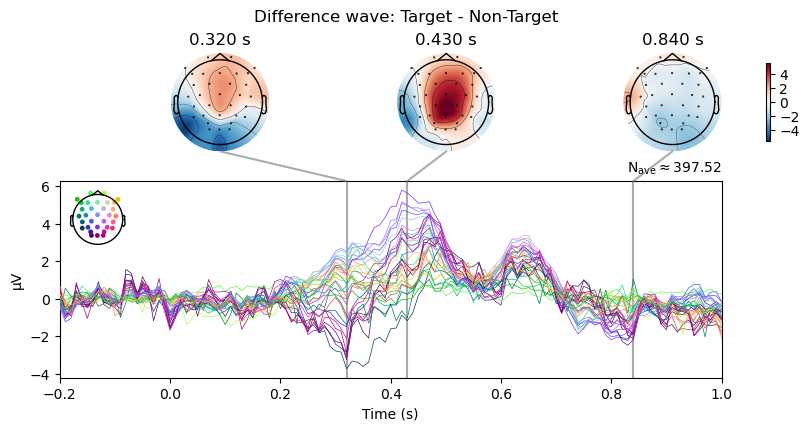

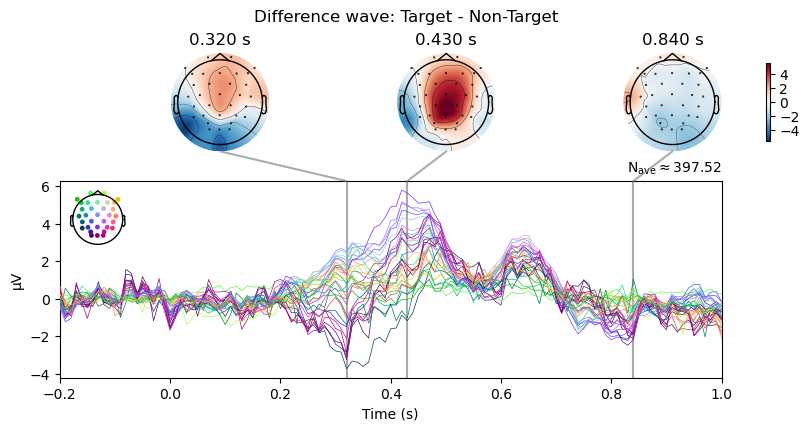

In [16]:
T_minus_NT = mne.combine_evoked([target, non_target], weights=[1, -1])
T_minus_NT.plot_joint(title="Difference wave: Target - Non-Target")

## 8) P300 window summary (300-600 ms)

ROI channels: ['Cz', 'Pz', 'CP1', 'CP2', 'P3', 'P4']
P300 window: 300-600 ms
Target mean amplitude: 2.10 µV
Non-target mean amplitude: -0.16 µV
Delta (T-NT): 2.26 µV
Target peak amplitude: 4.07 µV at 400.0 ms
Non-target peak amplitude: 0.76 µV at 600.0 ms


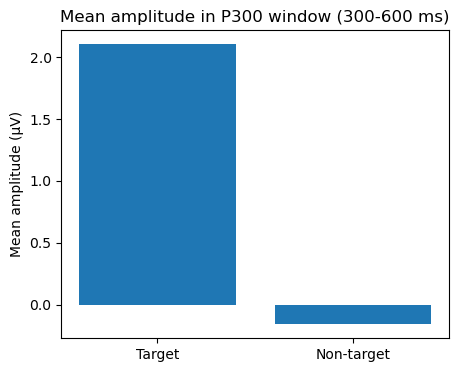

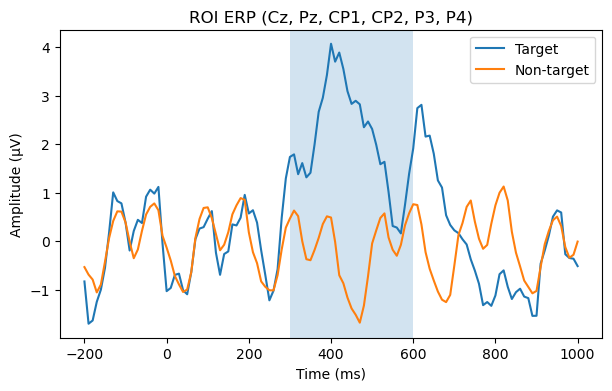

In [17]:
roi_candidates = ["Cz", "Pz", "CP1", "CP2", "P3", "P4"]
roi = [ch for ch in roi_candidates if ch in target.ch_names]

if len(roi) == 0:
    raise ValueError("No suitable centro-parietal ROI channels found.")

tmin_p300, tmax_p300 = 0.3, 0.6

target_roi = target.copy().pick(roi).data.mean(axis=0)
nontarget_roi = non_target.copy().pick(roi).data.mean(axis=0)
times = target.times

mask = (times >= tmin_p300) & (times <= tmax_p300)

# Mean amplitude in the P300 window
target_mean = target_roi[mask].mean() * 1e6
nontarget_mean = nontarget_roi[mask].mean() * 1e6
delta = target_mean - nontarget_mean

# Peak amplitude and latency in the same window
target_peak_idx = target_roi[mask].argmax()
nontarget_peak_idx = nontarget_roi[mask].argmax()

target_peak_amp = target_roi[mask][target_peak_idx] * 1e6
nontarget_peak_amp = nontarget_roi[mask][nontarget_peak_idx] * 1e6

target_peak_latency = times[mask][target_peak_idx] * 1000
nontarget_peak_latency = times[mask][nontarget_peak_idx] * 1000

print(f"ROI channels: {roi}")
print(f"P300 window: {tmin_p300*1000:.0f}-{tmax_p300*1000:.0f} ms")
print(f"Target mean amplitude: {target_mean:.2f} µV")
print(f"Non-target mean amplitude: {nontarget_mean:.2f} µV")
print(f"Delta (T-NT): {delta:.2f} µV")
print(f"Target peak amplitude: {target_peak_amp:.2f} µV at {target_peak_latency:.1f} ms")
print(f"Non-target peak amplitude: {nontarget_peak_amp:.2f} µV at {nontarget_peak_latency:.1f} ms")

# Bar plot of mean amplitudes
plt.figure(figsize=(5,4))
plt.bar(["Target", "Non-target"], [target_mean, nontarget_mean])
plt.ylabel("Mean amplitude (µV)")
plt.title("Mean amplitude in P300 window (300-600 ms)")
plt.show()

# ROI waveform plot
plt.figure(figsize=(7,4))
plt.plot(times * 1000, target_roi * 1e6, label="Target")
plt.plot(times * 1000, nontarget_roi * 1e6, label="Non-target")
plt.axvspan(tmin_p300 * 1000, tmax_p300 * 1000, alpha=0.2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title(f"ROI ERP ({', '.join(roi)})")
plt.legend()
plt.show()

## 9) EOG channels for artifact detection

In [18]:
# 7.1 Construct EOG proxy channels
veog_source = 'EOGv1' if 'EOGv1' in raw.ch_names else 'Fp1'
heog_raw = raw.copy().pick(['F9', 'F10'])
heog_raw = mne.set_bipolar_reference(
    heog_raw,
    anode='F9',
    cathode='F10',
    ch_name='HEOG'
)

# Vertical ocular channel: lower/vertical EOG electrode against frontal reference
veog_raw = raw.copy().pick([veog_source, 'Fp2'])
veog_raw = mne.set_bipolar_reference(
    veog_raw,
    anode=veog_source,
    cathode='Fp2',
    ch_name='VEOG'
)

print("Constructed HEOG as F9 - F10")
print(f"Constructed VEOG as {veog_source} - Fp2")

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=302730
    Range : 0 ... 302729 =      0.000 ...  3027.290 secs
Ready.
Added the following bipolar channels:
HEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=302730
    Range : 0 ... 302729 =      0.000 ...  3027.290 secs
Ready.
Added the following bipolar channels:
VEOG
Constructed HEOG as F9 - F10
Constructed VEOG as Fp1 - Fp2


Using matplotlib as 2D backend.


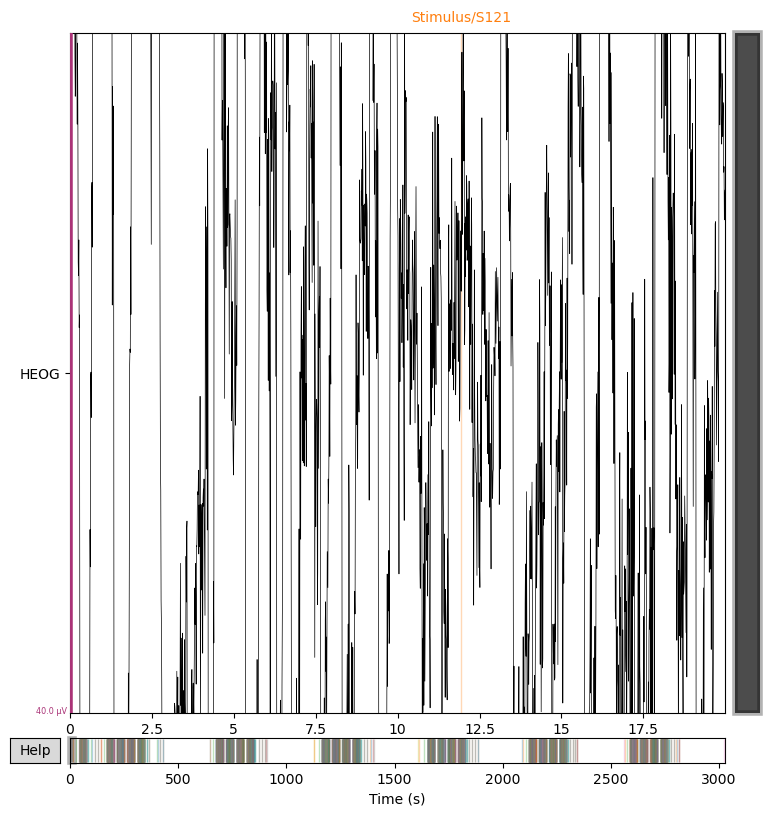

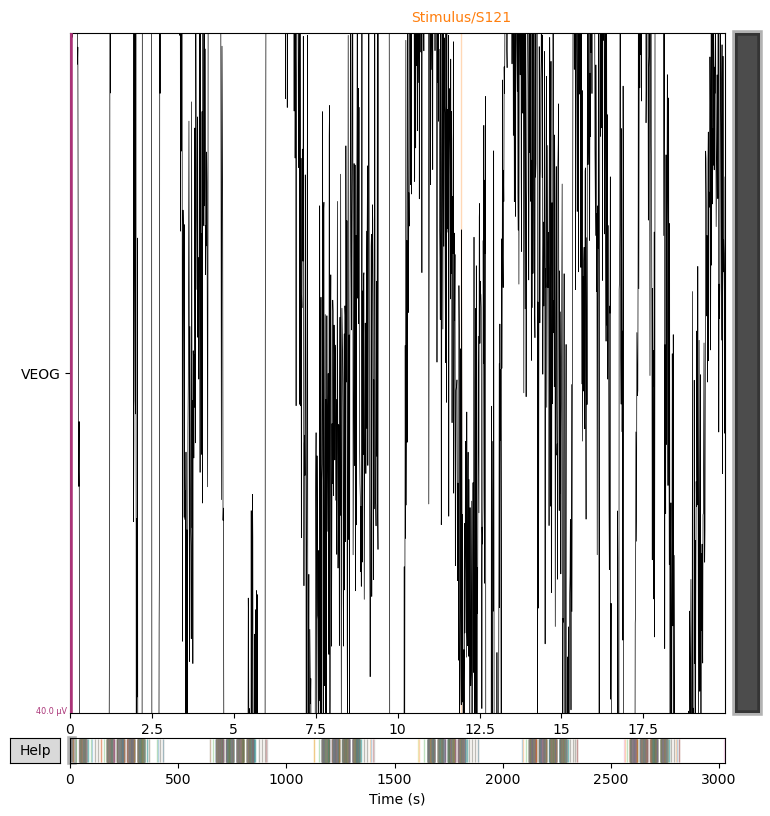

OCULAR ARTIFACT REJECTION
Rule: VEOG peak-to-peak > 150 µV
Epochs before cleaning: 3750
Rejected epochs:        0
Remaining epochs:       3750
Rejected proportion:    0.00%
Dropped 0 epochs: 

Clean target epochs:     452
Clean non-target epochs: 3298


In [19]:
# 7.2 Quick numeric inspection 7.3 Simple rejection rule and 7.4 Mark remove contaminaated epochs
heog_raw.plot(duration=20, title='HEOG signal')
veog_raw.plot(duration=20, title='VEOG signal')


blink_limit_uv = 150
blink_limit_v = blink_limit_uv * 1e-6

# 7.4 

# Pick the original VEOG-related channel inside the existing epochs object
veog_epoch_ch = 'EOGv1' if 'EOGv1' in epochs.ch_names else 'Fp1'

# Compute peak-to-peak amplitude in each epoch
veog_ep = epochs.copy().pick([veog_epoch_ch]).get_data()[:, 0, :]
veog_range = veog_ep.max(axis=1) - veog_ep.min(axis=1)

bad_epochs = veog_range > blink_limit_v
bad_numbers = np.flatnonzero(bad_epochs)


print("OCULAR ARTIFACT REJECTION")
print(f"Rule: VEOG peak-to-peak > {blink_limit_uv} µV")
print(f"Epochs before cleaning: {len(epochs)}")
print(f"Rejected epochs:        {len(bad_numbers)}")
print(f"Remaining epochs:       {len(epochs) - len(bad_numbers)}")
print(f"Rejected proportion:    {100 * len(bad_numbers) / len(epochs):.2f}%")

epochs_clean = epochs.copy()
epochs_clean.drop(bad_numbers, reason='ocular_artifact')

print(f"\nClean target epochs:     {len(epochs_clean['T'])}")
print(f"Clean non-target epochs: {len(epochs_clean['NT'])}")

In [20]:
# 7.5 Recompute the ERP analysis after artifact handling.

target_after_clean = epochs_clean['T'].average()
nontarget_after_clean = epochs_clean['NT'].average()
diff_after_clean = mne.combine_evoked(
    [target_after_clean, nontarget_after_clean],
    weights=[1, -1]
)

P300 SUMMARY: BEFORE VS AFTER CLEANING
Measure                         Before     After
------------------------------------------------
Target N                           452       452
Non-target N                      3298      3298
Target mean (µV)                  2.10      2.65
Non-target mean (µV)             -0.16     -0.19
T - NT (µV)                       2.26      2.84
No projector specified for this dataset. Please consider the method self.add_proj.


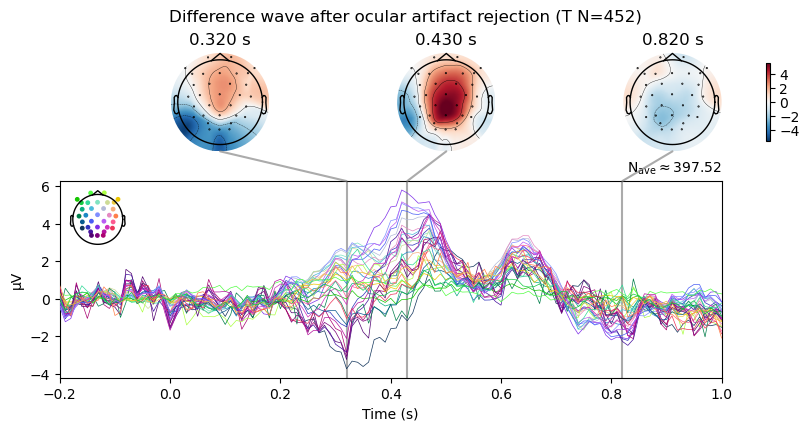

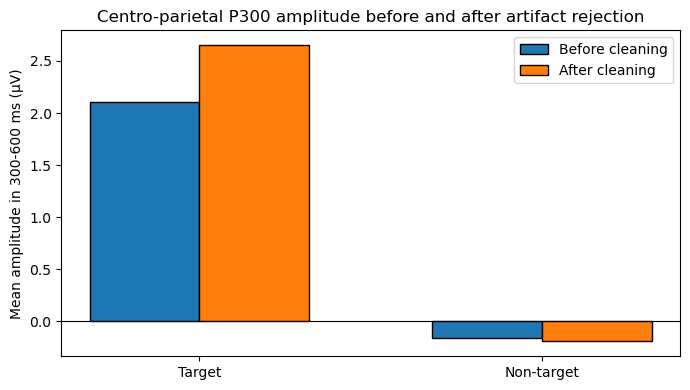

In [21]:
roi_pool = ['Cz', 'CPz', 'Pz']
roi_used = [ch for ch in roi_pool if ch in epochs_clean.ch_names]

if not roi_used:
    raise ValueError("No ROI channels found from ['Cz', 'CPz', 'Pz'].")

window_start, window_end = 0.30, 0.60
time_vec = target_after_clean.times
time_mask = (time_vec >= window_start) & (time_vec <= window_end)

# Before-cleaning values from Part 6 already assumed to exist:
# target, non_target, target_mean, nontarget_mean, delta

target_after_roi = target_after_clean.copy().pick(roi_used).data.mean(axis=0)
nontarget_after_roi = nontarget_after_clean.copy().pick(roi_used).data.mean(axis=0)

target_after_mean = target_after_roi[time_mask].mean() * 1e6
nontarget_after_mean = nontarget_after_roi[time_mask].mean() * 1e6
delta_after = target_after_mean - nontarget_after_mean

print("P300 SUMMARY: BEFORE VS AFTER CLEANING")
print(f"{'Measure':<28}{'Before':>10}{'After':>10}")
print("-" * 48)
print(f"{'Target N':<28}{target.nave:>10}{target_after_clean.nave:>10}")
print(f"{'Non-target N':<28}{non_target.nave:>10}{nontarget_after_clean.nave:>10}")
print(f"{'Target mean (µV)':<28}{target_mean:>10.2f}{target_after_mean:>10.2f}")
print(f"{'Non-target mean (µV)':<28}{nontarget_mean:>10.2f}{nontarget_after_mean:>10.2f}")
print(f"{'T - NT (µV)':<28}{delta:>10.2f}{delta_after:>10.2f}")

# Difference wave after cleaning
diff_after_clean.plot_joint(
    title=f"Difference wave after ocular artifact rejection (T N={target_after_clean.nave})",
    times=[0.32, 0.43, 0.82]
)

# Bar plot for ROI mean amplitude in the P300 window
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['Target', 'Non-target']
x = np.arange(len(labels))
bar_w = 0.32

ax.bar(
    x - bar_w / 2,
    [target_mean, nontarget_mean],
    width=bar_w,
    label='Before cleaning',
    edgecolor='black'
)

ax.bar(
    x + bar_w / 2,
    [target_after_mean, nontarget_after_mean],
    width=bar_w,
    label='After cleaning',
    edgecolor='black'
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean amplitude in 300-600 ms (µV)')
ax.set_title('Centro-parietal P300 amplitude before and after artifact rejection')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## 10) Part 8: Feature Extraction for Classification

In [22]:
# ── Part 8: Feature Extraction ───────────────────────────────────────────────
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
# 8.2 Selected channels: all EEG, excluding periocular electrodes
exclude_ch = ['Fp1', 'Fp2', 'F9', 'F10']
eeg_idx = mne.pick_types(epochs_clean.info, meg=False, eeg=True, exclude=exclude_ch)
ch_names = [epochs_clean.ch_names[i] for i in eeg_idx]

# Define the P300 time window
tmin_feat, tmax_feat = 0.200, 0.600   # seconds post-stimulus

times = epochs_clean.times
time_mask = (times >= tmin_feat) & (times <= tmax_feat)
n_times_in_window = time_mask.sum()

print("Feature extraction summary")
print(f"  Channels used       : {len(ch_names)}")
print(f"  Time window         : {tmin_feat*1000:.0f}–{tmax_feat*1000:.0f} ms")
print(f"  Time points/channel : {n_times_in_window}  "
      f"(at {epochs_clean.info['sfreq']:.0f} Hz → "
      f"{1000/epochs_clean.info['sfreq']:.0f} ms resolution)")
print(f"  Features per epoch  : {len(ch_names)} × {n_times_in_window} "
      f"= {len(ch_names)*n_times_in_window}")

#extract the windowed data: shape (n_epochs, n_channels, n_times)
X_raw = (epochs_clean
         .copy()
         .pick(ch_names)
         .get_data(copy=True)[:, :, time_mask])

n_epochs, n_ch, n_t = X_raw.shape
X_flat = X_raw.reshape(n_epochs, n_ch * n_t) * 1e6
print(f"\n  X shape (n_epochs × n_features): {X_flat.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
print(f"  Feature mean after scaling      : {X_scaled.mean():.6f}  (≈ 0)")
print(f"  Feature std  after scaling      : {X_scaled.std():.6f}  (≈ 1)")

#(1 = Target, 0 = Non-Target)
y = (epochs_clean.events[:, 2] == 112).astype(int)
print(f"\n  Targets     : {y.sum()}")
print(f"  Non-targets : {(y == 0).sum()}")
print(f"  Imbalance   : 1 : {(y==0).sum()/y.sum():.1f}  (T : NT)")


Feature extraction summary
  Channels used       : 28
  Time window         : 200–600 ms
  Time points/channel : 41  (at 100 Hz → 10 ms resolution)
  Features per epoch  : 28 × 41 = 1148

  X shape (n_epochs × n_features): (3750, 1148)
  Feature mean after scaling      : 0.000000  (≈ 0)
  Feature std  after scaling      : 1.000000  (≈ 1)

  Targets     : 452
  Non-targets : 3298
  Imbalance   : 1 : 7.3  (T : NT)


## 11) Part 9: Classification of target vs. non-target trials

Classification Performance (5-Fold CV)
ROC AUC Score:     0.7948
Balanced Accuracy: 0.7133


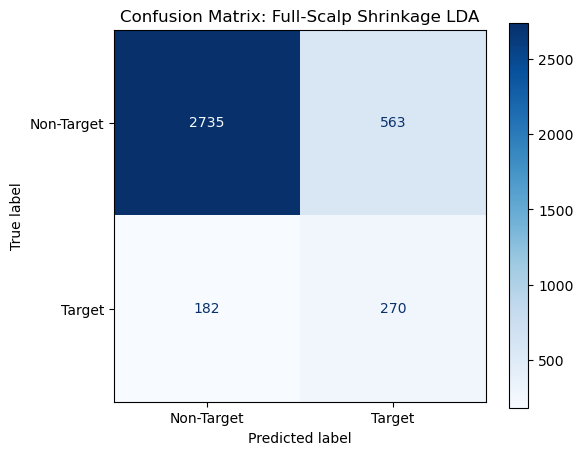

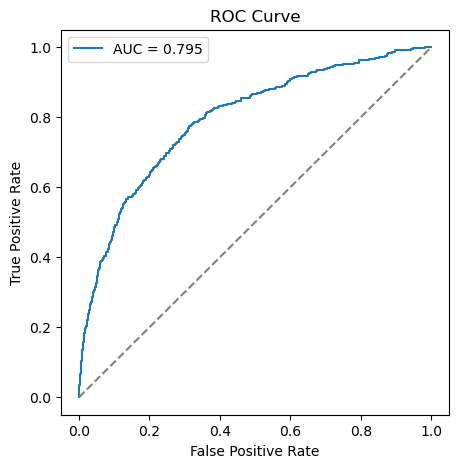

In [23]:
# 9.1, 9.2, 9.3, 9.4, 9.5: Classification, Cross-Validation, and Evaluation
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 9.1 Initialize Classifier with Scaling Pipeline
# Shrinkage LDA equipped with forced equal priors to shatter the extreme class imbalance bias.
clf = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto', priors=[0.5, 0.5])
)

# 9.2 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(clf, X_flat, y, cv=cv, method='predict')
y_proba = cross_val_predict(clf, X_flat, y, cv=cv, method='predict_proba')[:, 1]

# 9.3 & 9.4 Calculate Performance Metrics
auc = roc_auc_score(y, y_proba)
bal_acc = balanced_accuracy_score(y, y_pred)

print("Classification Performance (5-Fold CV)")
print(f"ROC AUC Score:     {auc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

# 9.5 Compute and visualize Confusion Matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Target', 'Target'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Confusion Matrix: Full-Scalp Shrinkage LDA")
plt.show()

fpr, tpr, _ = roc_curve(y, y_proba)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## 12) Part 10: Sequence averaging / authentication-style extension



Simulating sequence averaging...


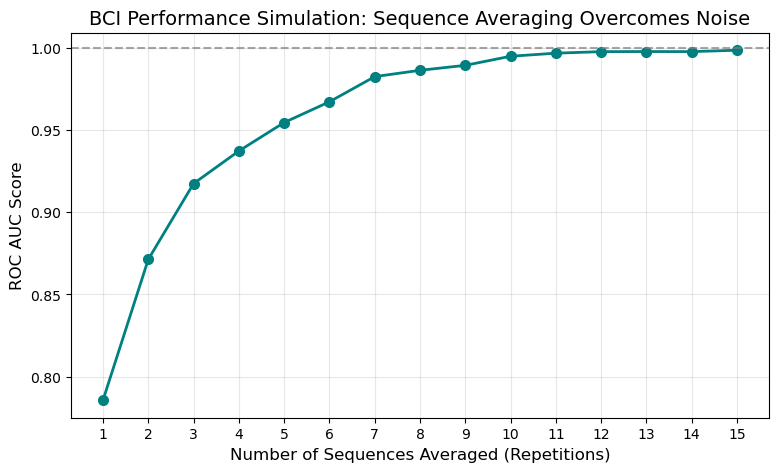

Base Single-Trial AUC (1 Rep): 0.786
Aggregated AUC (5 Reps):     0.955
Aggregated AUC (15 Reps):    0.999


In [24]:
# 10.1, 10.2, 10.3, 10.4: Simulate Sequence Averaging
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Extract the continuous probability floats generated in Part 9 (10.1)
target_probs = y_proba[y == 1]
nontarget_probs = y_proba[y == 0]

n_simulations = 1000  # Number of sequences to simulate
max_reps = 15         # Maximum number of sequence repetitions
auc_scores = []

print("Simulating sequence averaging...")

for r in range(1, max_reps + 1):
    # 10.2: Aggregate evidence across repeated trials
    # Randomly draw 'r' probabilities from the Target pool and average them
    t_draws = np.random.choice(target_probs, size=(n_simulations, r), replace=True)
    t_agg = np.mean(t_draws, axis=1)
    
    # Randomly draw 'r' probabilities from the Non-Target pool and average them
    nt_draws = np.random.choice(nontarget_probs, size=(n_simulations, r), replace=True)
    nt_agg = np.mean(nt_draws, axis=1)
    
    # 10.3: Evaluate detection performance dynamically
    y_sim = np.concatenate([np.ones(n_simulations), np.zeros(n_simulations)])
    y_pred_sim = np.concatenate([t_agg, nt_agg])
    
    auc = roc_auc_score(y_sim, y_pred_sim)
    auc_scores.append(auc)

# 10.4: Visualize the performance as a function of the number of repetitions
plt.figure(figsize=(9, 5))
plt.plot(range(1, max_reps + 1), auc_scores, marker='o', linestyle='-', color='teal', linewidth=2, markersize=7)
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.xlabel("Number of Sequences Averaged (Repetitions)", fontsize=12)
plt.ylabel("ROC AUC Score", fontsize=12)
plt.title("BCI Performance Simulation: Sequence Averaging Overcomes Noise", fontsize=14)
plt.xticks(range(1, max_reps + 1))
plt.grid(True, alpha=0.3)
plt.show()

print(f"Base Single-Trial AUC (1 Rep): {auc_scores[0]:.3f}")
print(f"Aggregated AUC (5 Reps):     {auc_scores[4]:.3f}")
print(f"Aggregated AUC ({max_reps} Reps):    {auc_scores[-1]:.3f}")
